In [1]:
#%matplotlib notebook
import numpy  as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
q = 1.60217662E-19  #elementary charge C
m = 9.10938356E-31 # electron mass kg
pi = np.pi

def bfield_from_ECR(frequency):
    B_field = (1E9*2*pi*m*frequency)/q
    return B_field

def freq_from_bfield(B):
    freq = (q*B)/(1E9*2*pi*m)
    return freq

def format_plot(xlabel,ylabel, title):
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel(xlabel,fontsize=20)
    plt.ylabel(ylabel,fontsize=20)
    plt.title(title, fontsize = 22)
    plt.ticklabel_format(useOffset=False)
    #plt.legend(fontsize = 16)

## Magnet Configuration

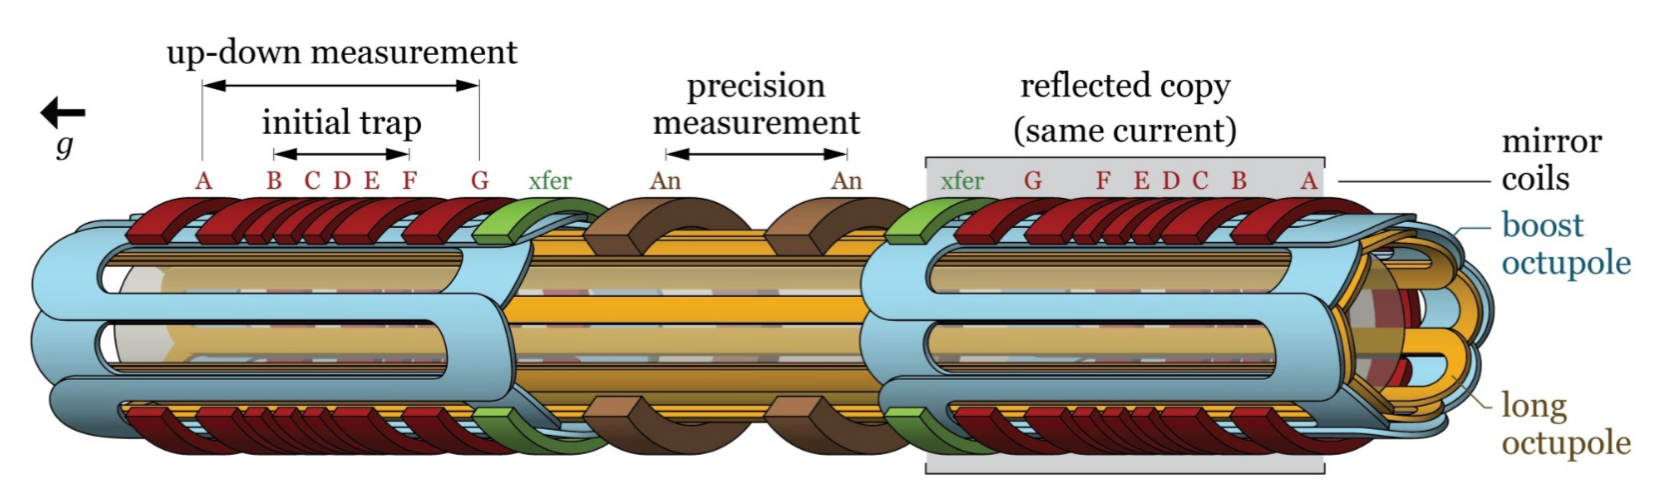



## 2D Model 

In [3]:
#some of the files are in the original folder but I made a new one for the magnets I added
path1 = 'Bfield_calculator_outputs/'
path2 = 'Bfield_calculator_outputs/Top Magnets/'

filename = path1 + "Babcock_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Position = np.array(data[:,0])*10
#Position = [p + 671-342.5+1 for p in Position] #matches positions to sequencer
Babcock_2D = np.array(data[:,1]) 


filename = path1 + "Babcock_shim_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Babcock_2D_shim = np.array(data[:,1]) 


filename = path1 + "MAGB_1A" #MaB in series with MgB
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
MirA_2D = np.array(data[:,1])


filename = path1 + "SOB_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
SoB_2D = np.array(data[:,1])


filename = path1 + "LOCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
LoC_2D = np.array(data[:,1])


filename = path1 + "OCT_1A"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Oc_2D = np.array(data[:,1])

filename = path2 + "tickle"
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
tickle = np.array(data[:,1])

filename = path2 + 'MB_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_B = np.array(data[:,1])

filename = path2 + 'MC_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_C = np.array(data[:,1])

filename = path2 + 'MD_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_D = np.array(data[:,1])

filename = path2 + 'ME_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_E = np.array(data[:,1])

filename = path2 + 'MF_1A'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_F = np.array(data[:,1])

filename = path2 + 'MA_T_1A'  #MaT in series with MgT
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_AT = np.array(data[:,1])

filename = path2 + 'MbT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_bT = np.array(data[:,1])

filename = path2 + 'McT'  
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_cT = np.array(data[:,1])

filename = path2 + 'MdT'
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_dT = np.array(data[:,1])

filename = path2 + 'MeT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_eT = np.array(data[:,1])*2

filename = path2 + 'MfT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Mirror_fT = np.array(data[:,1])

filename = path2 + 'OcT' 
data = np.loadtxt(filename, skiprows=1, usecols = (0,1,2), delimiter ='\t')
Octupole_B = np.array(data[:,1])

#this will calculate the B field given some currents
def field_2D_calculation(current):
    return Babcock_2D*current[0] + MirA_2D*current[1]  + SoB_2D*current[2] + LoC_2D*current[3] + Oc_2D*current[4] + tickle*current[5] + Babcock_2D_shim*current[6] + Mirror_B*current[7] + Mirror_C*current[8] + Mirror_D*current[9] + Mirror_E*current[10] + Mirror_F*current[11] + Mirror_AT*current[12] + Mirror_bT*current[13] + Mirror_cT*current[14] + Mirror_dT*current[15] + Mirror_eT*current[16] + Mirror_fT*current[17] + Octupole_B*current[18]


In [4]:
list_stringa = ["PreGravity_20mT_well", "GravityRelease_17mT_well" ,"GravityRelease_5mT_well", "GravityRelease_2p5mT_well"] 
list_MB      = [3.4702, 2.9122, 0.9416, 0.5328]
#list_targets = [-1.25, -0.75, -0.5, -0.375, -0.25, 0, 0.25, 0.5, 0.75, 1.25]
list_targets = [+1, -1]

In [5]:
Zmin                 = -0.605  # m
Zmax                 = -0.481  # m
Zmid                 = -0.5434 # m
zacceptance_min      = -0.775  # m
zacceptance_max      = -0.325  # m

In [6]:
#magnet currents
B = 191 
BS = 5
MA = 0.39 #in series with MG
tickle_g = 0 
LOc = 0
Oc = 220
SB = 0


MB = 0.9416
MF = MB 

MC = 0.2767
MD = 0.2802 
ME = 0.2907 


MAT = 0 #in series with MGT
MbT = 0
McT = 0
MdT = 0
MeT = 0
MfT = 0

OcT = 0


currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

In [7]:
import optuna

def compute_bias_from_delta(delta: float) -> float:
    MF = MB - delta

    currents = [B, MA, SB, LOc, Oc, tickle_g, BS,
                MB, MC, MD, ME, MF,
                0, MbT, McT, MdT, MeT, MfT, OcT]

    field_2D = field_2D_calculation(currents) / 1e4

    index_mid = np.argmin(np.abs(Position - Zmid * 1e3))
    bias_g = -(np.max(field_2D[:index_mid]) - np.max(field_2D[index_mid:])) * 1e4 / 2.2
    return float(bias_g)

def objective(trial: optuna.Trial) -> float:
    # range di ricerca: scegli tu (importante!)
    delta = trial.suggest_float("delta_MB_minus_MF", -0.1, 0.1)  # esempio 0..0.2 A
    bias = compute_bias_from_delta(delta)

    # Minimizza l’errore rispetto al target
    err = abs(bias - BIAS_TARGET)

    # (opzionale) salva valori utili nei risultati
    trial.set_user_attr("bias", bias)
    trial.set_user_attr("MF", MB - delta)

    return err

In [8]:
# Save the file in Folder
# z (mm) - Bz on axis,Total potential (T) - Bz on axis,z (mm) - Min |B| on wall,Total potential (T) - Min |B| on wall

def save_file(BIAS_G, Position, field_2D):
    dtype = [
        ('z_mm__Bz_on_axis', 'f8'),
        ('Total_potential_T__Bz_on_axis', 'f8'),
    ]
    
    print(dtype[0][0])
    
    N = len(Position)
    data_new = np.empty(N, dtype=dtype)
    print(type(Position))
    
    data_new['z_mm__Bz_on_axis'] = [p for p in Position]
    data_new['Total_potential_T__Bz_on_axis'] = field_2D
    
    out_file = f"../toy/Bfield_notebook/{stringa}_{(str(round(BIAS_G,2)).replace('.','p') + 'g')}.csv"
    print(dtype[0][0] + dtype[1][0])
    
    header = dtype[0][0] + "," + dtype[1][0]
    
    np.savetxt(
        out_file,
        data_new,
        delimiter=",",
        header=header,
        comments=''   # IMPORTANTISSIMO: evita il "#"
    )

In [9]:
TOL = 1e-3  # millesimo (stessa unità del tuo bias)

def stop_when_good_enough(study: optuna.Study, trial: optuna.Trial):
    if study.best_value is not None and study.best_value <= TOL:
        study.stop()

list_biases = []
for stringa, current in zip(list_stringa,list_MB):
    MB  = current
    for bias in list_targets:
        BIAS_TARGET = bias
    
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials = 300, callbacks=[stop_when_good_enough])
        
        best = study.best_trial
        best_delta = best.params["delta_MB_minus_MF"]
        best_MF = MB - best_delta
        best_bias = best.user_attrs["bias"]
        
        print("Best delta (MB - MF) =", best_delta)
        print("Best MF =", best_MF)
        print("Bias ottenuto =", best_bias)
        print("Errore =", best.value)
    
        MF = MB - best_delta
    
        currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
        #currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]
        
        field_2D = field_2D_calculation(currents)
        field_2D = field_2D/1e4
        BIAS_G = compute_bias_from_delta(best_delta)
        
        save_file(BIAS_G, Position, field_2D )
        list_biases.append((str(round(BIAS_G,2)).replace('.','p') + 'g'))
print( list(set(list_biases)))

[I 2026-02-11 13:52:14,478] A new study created in memory with name: no-name-2de679da-f45e-4049-8aa7-9709d8ad2564
[I 2026-02-11 13:52:14,482] Trial 0 finished with value: 3.4326969344239995 and parameters: {'delta_MB_minus_MF': 0.07972670101200144}. Best is trial 0 with value: 3.4326969344239995.
[I 2026-02-11 13:52:14,485] Trial 1 finished with value: 1.4378193097701297 and parameters: {'delta_MB_minus_MF': 0.036335521507362106}. Best is trial 1 with value: 1.4378193097701297.
[I 2026-02-11 13:52:14,488] Trial 2 finished with value: 1.2303640939055833 and parameters: {'delta_MB_minus_MF': 0.031823101096477235}. Best is trial 2 with value: 1.2303640939055833.
[I 2026-02-11 13:52:14,490] Trial 3 finished with value: 3.983689063741256 and parameters: {'delta_MB_minus_MF': 0.09171149551434774}. Best is trial 2 with value: 1.2303640939055833.
[I 2026-02-11 13:52:14,492] Trial 4 finished with value: 4.442863895598438 and parameters: {'delta_MB_minus_MF': -0.09157697669317233}. Best is trial

Best delta (MB - MF) = 0.005078556950705083
Best MF = 3.465121443049295
Bias ottenuto = 0.9991966902696395
Errore = 0.0008033097303604686
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-11 13:52:15,390] Trial 40 finished with value: 3.6929553235698442 and parameters: {'delta_MB_minus_MF': -0.03176289336519697}. Best is trial 23 with value: 0.026801866386371498.
[I 2026-02-11 13:52:15,394] Trial 41 finished with value: 0.21388462111265294 and parameters: {'delta_MB_minus_MF': 0.04391141341625987}. Best is trial 23 with value: 0.026801866386371498.
[I 2026-02-11 13:52:15,400] Trial 42 finished with value: 0.7612197906353104 and parameters: {'delta_MB_minus_MF': 0.06512120094558392}. Best is trial 23 with value: 0.026801866386371498.
[I 2026-02-11 13:52:15,405] Trial 43 finished with value: 1.0796106277274737 and parameters: {'delta_MB_minus_MF': 0.025080748271409544}. Best is trial 23 with value: 0.026801866386371498.
[I 2026-02-11 13:52:15,411] Trial 44 finished with value: 5.809551136747919 and parameters: {'delta_MB_minus_MF': -0.07780160157132492}. Best is trial 23 with value: 0.026801866386371498.
[I 2026-02-11 13:52:15,416] Trial 45 finished with value:

Best delta (MB - MF) = 0.0485415724220101
Best MF = 3.42165842757799
Bias ottenuto = -0.9989835402195042
Errore = 0.0010164597804958042
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-11 13:52:17,024] Trial 33 finished with value: 0.1126800340513936 and parameters: {'delta_MB_minus_MF': 0.0023597746151810288}. Best is trial 30 with value: 0.009646284419229323.
[I 2026-02-11 13:52:17,030] Trial 34 finished with value: 1.280294948620032 and parameters: {'delta_MB_minus_MF': -0.0279392406083652}. Best is trial 30 with value: 0.009646284419229323.
[I 2026-02-11 13:52:17,036] Trial 35 finished with value: 1.06189470751685 and parameters: {'delta_MB_minus_MF': 0.023006426708377777}. Best is trial 30 with value: 0.009646284419229323.
[I 2026-02-11 13:52:17,042] Trial 36 finished with value: 1.7493676609904298 and parameters: {'delta_MB_minus_MF': 0.03795985641258728}. Best is trial 30 with value: 0.009646284419229323.
[I 2026-02-11 13:52:17,047] Trial 37 finished with value: 1.8146053353035727 and parameters: {'delta_MB_minus_MF': -0.039561185540366556}. Best is trial 30 with value: 0.009646284419229323.
[I 2026-02-11 13:52:17,052] Trial 38 finished with value: 

...

Best delta (MB - MF) = 0.025770399215449737
Best MF = 0.9158296007845502
Bias ottenuto = -1.000671995719162
Errore = 0.0006719957191620995
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-11 13:52:21,290] Trial 34 finished with value: 1.0903603042652574 and parameters: {'delta_MB_minus_MF': -0.046141297517378915}. Best is trial 24 with value: 0.02605667913305354.
[I 2026-02-11 13:52:21,297] Trial 35 finished with value: 1.3193532574587785 and parameters: {'delta_MB_minus_MF': 0.006616409928983064}. Best is trial 24 with value: 0.02605667913305354.
[I 2026-02-11 13:52:21,303] Trial 36 finished with value: 1.7994234077561244 and parameters: {'delta_MB_minus_MF': -0.06165885133609765}. Best is trial 24 with value: 0.02605667913305354.
[I 2026-02-11 13:52:21,308] Trial 37 finished with value: 0.10142795047335973 and parameters: {'delta_MB_minus_MF': -0.024498920488415232}. Best is trial 24 with value: 0.02605667913305354.
[I 2026-02-11 13:52:21,314] Trial 38 finished with value: 0.38111527242020937 and parameters: {'delta_MB_minus_MF': -0.013937675187718407}. Best is trial 24 with value: 0.02605667913305354.
[I 2026-02-11 13:52:21,320] Trial 39 finished with valu

Best delta (MB - MF) = -0.022304082780445326
Best MF = 0.5551040827804454
Bias ottenuto = 1.0011364705767274
Errore = 0.0011364705767273886
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis


[I 2026-02-11 13:52:23,133] Trial 30 finished with value: 3.934011021003193 and parameters: {'delta_MB_minus_MF': -0.06460424578919326}. Best is trial 29 with value: 0.11995211343652601.
[I 2026-02-11 13:52:23,138] Trial 31 finished with value: 0.12128423603461458 and parameters: {'delta_MB_minus_MF': 0.018870427303228555}. Best is trial 29 with value: 0.11995211343652601.
[I 2026-02-11 13:52:23,144] Trial 32 finished with value: 0.3222478691651761 and parameters: {'delta_MB_minus_MF': 0.014467894378114158}. Best is trial 29 with value: 0.11995211343652601.
[I 2026-02-11 13:52:23,149] Trial 33 finished with value: 1.452699422897657 and parameters: {'delta_MB_minus_MF': -0.010297035017478407}. Best is trial 29 with value: 0.11995211343652601.
[I 2026-02-11 13:52:23,156] Trial 34 finished with value: 0.3159987285682646 and parameters: {'delta_MB_minus_MF': 0.014604795004372204}. Best is trial 29 with value: 0.11995211343652601.
[I 2026-02-11 13:52:23,161] Trial 35 finished with value: 0.

Best delta (MB - MF) = 0.021514870948623886
Best MF = 0.5112851290513761
Bias ottenuto = -0.9994274114703701
Errore = 0.000572588529629936
z_mm__Bz_on_axis
<class 'numpy.ndarray'>
z_mm__Bz_on_axisTotal_potential_T__Bz_on_axis
['-1p0g', '1p0g']


In [10]:
MF = MB - best_delta

currents =  [B,MA,SB,LOc,Oc, tickle_g, BS, MB, MC, MD, ME, MF, 0, MbT, McT, MdT, MeT, MfT, OcT]
#currents = [B,70,0,LOc,Oc, tickle_g, BS, -4.6, 1.8, 1.6, 1.8, -4.8, MAT, MbT, McT, MdT, MeT, MfT, OcT]

field_2D = field_2D_calculation(currents)
field_2D = field_2D/1e4

## Plotting

In [11]:
# Compute Bias
index_mid = np.argmin(np.abs(Position - Zmid*1e3)) # index relative to the potential well center
print(Position[index_mid])
Bottom_Well = (field_2D)[index_mid]

massimo = np.max((field_2D)[:index_mid]); 
BIAS_G = (np.max((field_2D)[:index_mid]) - np.max((field_2D)[index_mid:]))*1e4/2.2
print(BIAS_G)

-543.4000000000001
0.9994274114703701


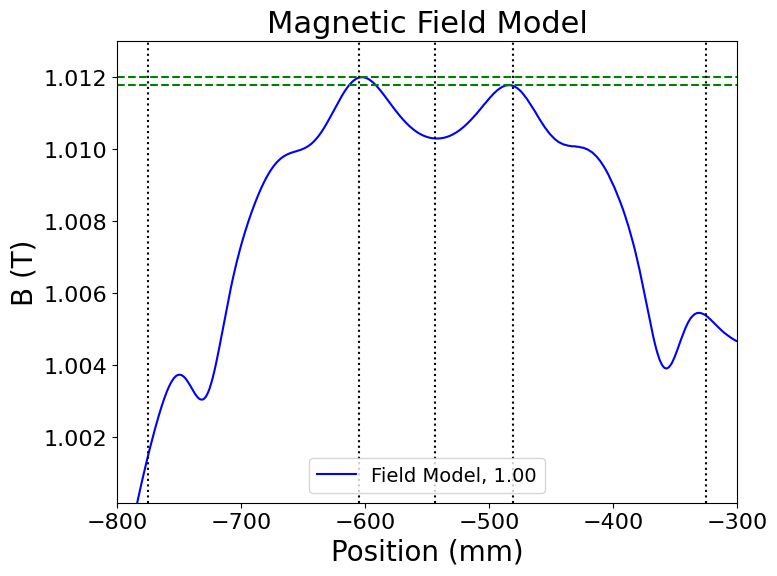

In [12]:
plt.figure(figsize=(8,6))
plt.plot([p for p in Position], field_2D, 'b', label = f'Field Model, {BIAS_G:.2f}')

plt.ylim(Bottom_Well*0.99, massimo*1.001)
plt.xlim( -800, -300)

plt.axhline(np.max((field_2D)[:index_mid]), linestyle = "--", color = "green")
plt.axhline(np.max((field_2D)[index_mid:]), linestyle = "--", color = "green")
plt.axvline(Zmin*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmax*1e3, color = "black", linestyle = "dotted")
plt.axvline(Zmid*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_min*1e3, color = "black", linestyle = "dotted")
plt.axvline(zacceptance_max*1e3, color = "black", linestyle = "dotted")
plt.legend(fontsize = 14, loc = "lower center")
format_plot('Position (mm)', 'B (T)', 'Magnetic Field Model')

In [13]:
# plt.figure(figsize = (8,6))

# plt.plot(Position, [freq_from_bfield(b/1e4) for b in field_2D], color = 'k', label = 'Field Model')

# format_plot('Position (mm)', 'Frequency (GHz)', '')